# AI-Based Microprocessor Performance Analysis

## Project Overview

Microprocessors are the brain of every modern computer system. Their performance depends on various factors such as the number of cores, threads, clock speed, cache memory, and power consumption.

This project analyzes different processors using Python. It also builds a Machine Learning model to predict the benchmark performance score of a processor based on its specifications.

### Objectives

- Analyze processor specifications.
- Visualize processor performance.
- Study relationships between hardware features.
- Build a Machine Learning model for prediction.
- Predict the performance of a new processor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Creating the Dataset

Since this project is for educational purposes, we first create a small dataset containing processor specifications and benchmark scores.

Each processor includes:

- Number of Cores
- Number of Threads
- Base Clock Speed
- Boost Clock Speed
- TDP (Power Consumption)
- Cache Size
- Benchmark Score

In [2]:
data = {
    "Processor": [
        "i3-12100",
        "i5-12400",
        "i7-12700",
        "i9-12900K",
        "Ryzen5 5600X",
        "Ryzen7 5800X",
        "Ryzen9 5900X"
    ],
    "Cores": [4,6,12,16,6,8,12],
    "Threads": [8,12,20,24,12,16,24],
    "BaseClock": [3.3,2.5,2.1,3.2,3.7,3.8,3.7],
    "BoostClock": [4.3,4.4,4.9,5.2,4.6,4.7,4.8],
    "TDP": [60,65,65,125,65,105,105],
    "Cache": [12,18,25,30,35,36,64],
    "Score": [9200,19500,32000,41000,22000,28000,39000]
}

df = pd.DataFrame(data)

df

,Processor,Cores,Threads,BaseClock,BoostClock,TDP,Cache,Score
0,i3-12100,4,8,3.3,4.3,60,12,9200
1,i5-12400,6,12,2.5,4.4,65,18,19500
2,i7-12700,12,20,2.1,4.9,65,25,32000
3,i9-12900K,16,24,3.2,5.2,125,30,41000
4,Ryzen5 5600X,6,12,3.7,4.6,65,35,22000
5,Ryzen7 5800X,8,16,3.8,4.7,105,36,28000
6,Ryzen9 5900X,12,24,3.7,4.8,105,64,39000


# Dataset Information

Before performing any analysis, it is important to understand the dataset.

This section displays:

- Number of rows and columns
- Data types
- Statistical summary

In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Processor   7 non-null      object 
 1   Cores       7 non-null      int64  
 2   Threads     7 non-null      int64  
 3   BaseClock   7 non-null      float64
 4   BoostClock  7 non-null      float64
 5   TDP         7 non-null      int64  
 6   Cache       7 non-null      int64  
 7   Score       7 non-null      int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 580.0+ bytes


,Cores,Threads,BaseClock,BoostClock,TDP,Cache,Score
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,9.142857,16.571429,3.185714,4.700000,84.285714,31.428571,27242.857143
std,4.298394,6.294366,0.654290,0.305505,26.524921,16.811277,11281.822717
min,4.000000,8.000000,2.100000,4.300000,60.000000,12.000000,9200.000000
25%,6.000000,12.000000,2.850000,4.500000,65.000000,21.500000,20750.000000
50%,8.000000,16.000000,3.300000,4.700000,65.000000,30.000000,28000.000000
75%,12.000000,22.000000,3.700000,4.850000,105.000000,35.500000,35500.000000
max,16.000000,24.000000,3.800000,5.200000,125.000000,64.000000,41000.000000


# Processor Performance Analysis

The first visualization compares the benchmark scores of different processors.

Higher benchmark scores indicate better overall processor performance.

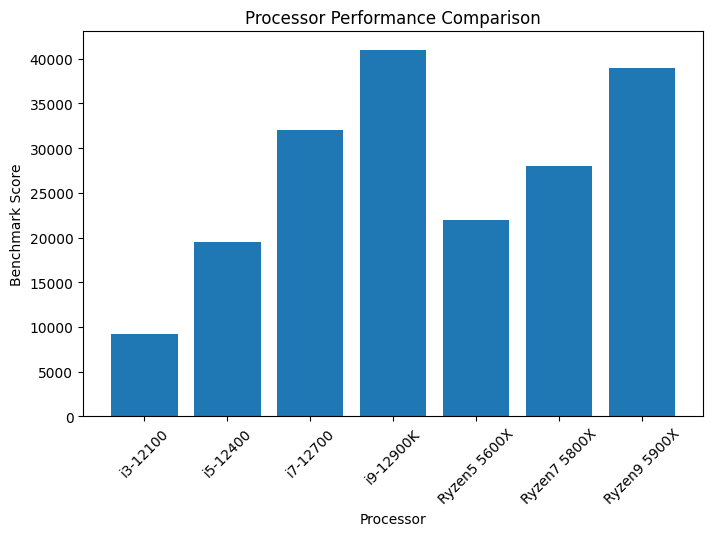

In [4]:
plt.figure(figsize=(8,5))

plt.bar(df["Processor"], df["Score"])

plt.xticks(rotation=45)

plt.xlabel("Processor")

plt.ylabel("Benchmark Score")

plt.title("Processor Performance Comparison")

plt.show()

# Core Count Analysis

The number of cores plays an important role in multitasking and parallel processing.

This graph compares the number of cores available in each processor.

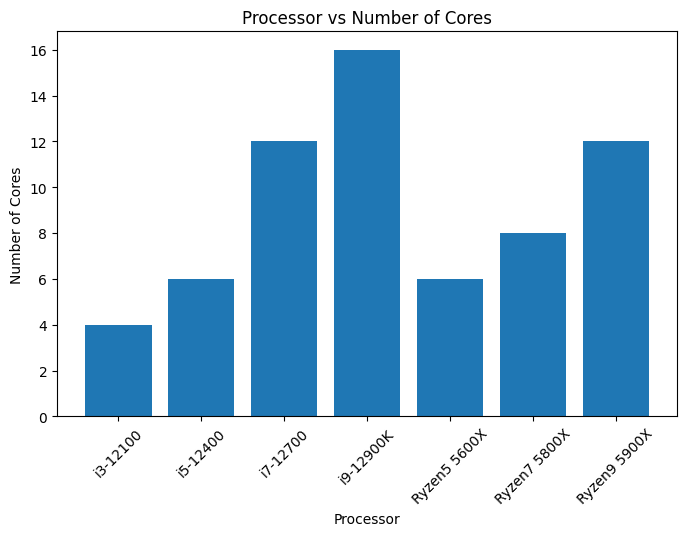

In [5]:
plt.figure(figsize=(8,5))

plt.bar(df["Processor"], df["Cores"])

plt.xticks(rotation=45)

plt.xlabel("Processor")

plt.ylabel("Number of Cores")

plt.title("Processor vs Number of Cores")

plt.show()

# Correlation Analysis

Correlation helps identify relationships between processor features.

Values closer to +1 indicate a strong positive relationship, while values closer to -1 indicate a strong negative relationship.

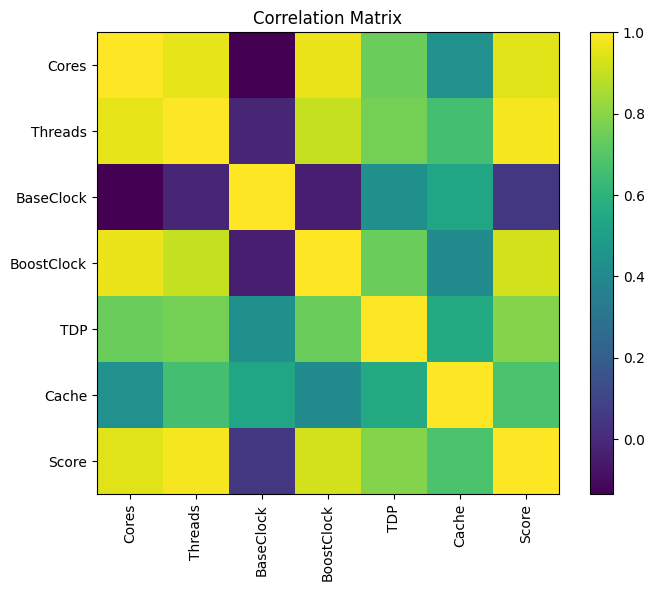

In [6]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

# Preparing Data for Machine Learning

The dataset is divided into:

- Features (Input Variables)
- Target Variable (Benchmark Score)

The dataset is then split into training and testing sets.

In [7]:
X = df[["Cores","Threads","BaseClock","BoostClock","TDP","Cache"]]

y = df["Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Training the Machine Learning Model

A Random Forest Regressor is used to learn the relationship between processor specifications and benchmark scores.

The trained model is then evaluated using Mean Absolute Error (MAE) and R² Score.

In [8]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))

print("R² Score:", r2_score(y_test, predictions))

Mean Absolute Error: 10875.0
R² Score: -4.457126967668961


# Predicting the Performance of a New Processor

The trained model can estimate the benchmark score of a processor based on its hardware specifications.

The sample values below represent a hypothetical processor.

In [9]:
new_processor = [[10,20,3.8,5.0,95,32]]

prediction = model.predict(new_processor)

print("Predicted Benchmark Score:", prediction[0])

Predicted Benchmark Score: 32090.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# Feature Importance

Feature Importance shows which processor specifications have the greatest impact on benchmark performance.

This helps us understand which hardware components contribute most to overall processor speed.

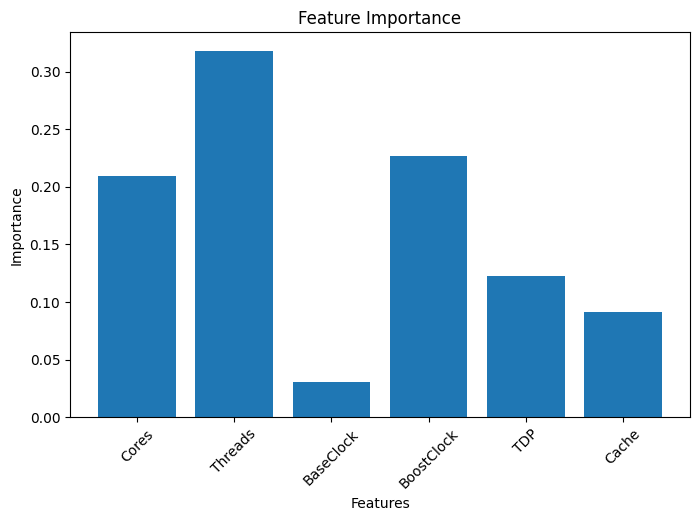

In [10]:
importance = model.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(X.columns, importance)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

# Conclusion

## Summary

This project successfully analyzed various processor specifications and benchmark scores using Python.

### Achievements

- Created a processor dataset
- Performed exploratory data analysis
- Visualized processor performance
- Studied feature correlations
- Built a Machine Learning prediction model
- Predicted benchmark scores for new processors

## Future Scope

- Use a larger real-world processor dataset
- Compare Intel, AMD, and ARM processors
- Develop a web application for processor performance prediction
- Improve prediction accuracy using advanced Machine Learning algorithms